# Vietnamese Word2Vec + LSTM baseline for UIT-VSFC

This baseline uses Vietnamese word segmentation with Underthesea, pre-trained Vietnamese Word2Vec embeddings, and an LSTM classifier. The external embeddings are downloaded separately; the LSTM is trained on UIT-VSFC.

Thiết lập đường dẫn, split đánh giá và các hyperparameter ở một nơi để dễ tái sử dụng.

In [21]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from gensim.models import KeyedVectors
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from underthesea import word_tokenize

SPLIT = "valid"  # Change to "test" only for final evaluation.
if SPLIT not in {"valid", "test"}:
    raise ValueError("SPLIT must be 'valid' or 'test'.")

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "Outputs"
WORD2VEC_PATH = PROJECT_ROOT / "embeddings" / "wiki.vi.model.bin.gz"
MODEL_PATH = PROJECT_ROOT / "models" / "lstm_sentiment.pt"
TRAIN_PATH = DATA_DIR / "UIT-VSFC_train.csv"
EVAL_PATH = DATA_DIR / f"UIT-VSFC_{SPLIT}.csv"
WORD2VEC_SOURCE = (
    "https://thiaisotajppub.s3-ap-northeast-1.amazonaws.com/"
    "publicfiles/wiki.vi.model.bin.gz"
)

LABEL_NAMES = ["negative", "neutral", "positive"]
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABEL_NAMES)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}

HIDDEN_DIM = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3

torch.manual_seed(42)
device = torch.device("cpu")
print(f"Evaluation split: {SPLIT} | device: {device}")

Evaluation split: valid | device: cpu


## 1. Load and clean data

Official train and evaluation splits are kept separate. Missing rows are removed before lightweight text normalization.

In [22]:
train_df = pd.read_csv(TRAIN_PATH).dropna(subset=["text", "label"]).copy()
eval_df = (
    pd.read_csv(EVAL_PATH)
    .dropna(subset=["text", "label"])
    .reset_index(drop=True)
)
if SPLIT == "valid":
    eval_df["sample_id"] = eval_df.index
    eval_df["raw_text"] = eval_df["text"].astype(str)

for df in (train_df, eval_df):
    df["text"] = (
        df["text"].astype(str).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    )
    df["label"] = df["label"].astype(str).str.strip().str.lower()

unknown_labels = (set(train_df["label"]) | set(eval_df["label"])) - set(LABEL_NAMES)
if unknown_labels:
    raise ValueError(f"Unexpected labels: {sorted(unknown_labels)}")

distribution = pd.concat(
    [train_df["label"].value_counts(), eval_df["label"].value_counts()], axis=1
).fillna(0).astype(int)
distribution.columns = ["train", SPLIT]
display(distribution.reindex(LABEL_NAMES))

,train,valid
label,,
negative,5325,705
neutral,458,73
positive,5643,805


## 2. Vietnamese tokenization and vocabulary

Underthesea performs Vietnamese-specific word segmentation. Length statistics and `MAX_LEN` are computed from the segmented train text, and the vocabulary is built from train only to prevent data leakage.

In [23]:
def tokenize_text(text):
    segmented = word_tokenize(text, format="text")
    return segmented.split()


train_tokens = train_df["text"].apply(tokenize_text).tolist()
eval_tokens = eval_df["text"].apply(tokenize_text).tolist()
train_lengths = np.array([len(tokens) for tokens in train_tokens])

length_stats = pd.Series({
    "median": np.median(train_lengths),
    "p90": np.percentile(train_lengths, 90),
    "p95": np.percentile(train_lengths, 95),
    "max": train_lengths.max(),
})
MAX_LEN = max(1, int(np.ceil(length_stats["p95"])))
display(length_stats.to_frame("tokens").round(1))
print(f"MAX_LEN = {MAX_LEN}")

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
token_counts = Counter(token for tokens in train_tokens for token in tokens)
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for token, _ in token_counts.most_common():
    vocab[token] = len(vocab)

PAD_IDX, UNK_IDX = vocab[PAD_TOKEN], vocab[UNK_TOKEN]
print(f"Vocabulary size: {len(vocab):,}")

,tokens
median,9.0
p90,21.0
p95,26.8
max,122.0


MAX_LEN = 27
Vocabulary size: 4,011


## 3. Load pretrained Vietnamese Word2Vec

The external `wiki.vi.model.bin.gz` embedding from [sonvx/word2vecVN](https://github.com/sonvx/word2vecVN) must be downloaded separately and placed in `embeddings/`. It was pretrained on Vietnamese Wikipedia, not on UIT-VSFC.

In [24]:
if not WORD2VEC_PATH.exists():
    raise FileNotFoundError(
        "Pretrained Word2Vec model not found. Download wiki.vi.model.bin.gz "
        "from sonvx/word2vecVN and place it in the embeddings/ folder."
    )

word_vectors = KeyedVectors.load_word2vec_format(
    str(WORD2VEC_PATH), binary=True
)
EMBEDDING_DIM = word_vectors.vector_size
rng = np.random.default_rng(42)
embedding_matrix = rng.normal(
    0.0, 0.05, size=(len(vocab), EMBEDDING_DIM)
).astype(np.float32)
embedding_matrix[PAD_IDX] = 0.0

found = 0
for token, token_id in vocab.items():
    if token not in {PAD_TOKEN, UNK_TOKEN} and token in word_vectors:
        embedding_matrix[token_id] = word_vectors[token]
        found += 1

vocab_tokens = len(vocab) - 2
oov = vocab_tokens - found
coverage = 100 * found / vocab_tokens
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"Embedding coverage: {coverage:.1f}%")
print(f"Found: {found:,} | OOV: {oov:,}")
del word_vectors

Embedding dimension: 400
Embedding coverage: 35.2%
Found: 1,412 | OOV: 2,597


## 4. Encode text and create DataLoaders

Each sequence is mapped to token IDs, truncated to `MAX_LEN`, then padded with `<PAD>`.

In [25]:
def encode_texts(token_lists):
    encoded = []
    for tokens in token_lists:
        token_ids = [vocab.get(token, UNK_IDX) for token in tokens[:MAX_LEN]]
        token_ids += [PAD_IDX] * (MAX_LEN - len(token_ids))
        encoded.append(token_ids)
    return torch.tensor(encoded, dtype=torch.long)


X_train = encode_texts(train_tokens)
X_eval = encode_texts(eval_tokens)
y_train = torch.tensor(train_df["label"].map(LABEL_TO_ID).to_numpy(), dtype=torch.long)
y_eval = torch.tensor(eval_df["label"].map(LABEL_TO_ID).to_numpy(), dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
)
eval_loader = DataLoader(
    TensorDataset(X_eval, y_eval), batch_size=BATCH_SIZE, shuffle=False
)
print(f"Train tensor: {tuple(X_train.shape)} | {SPLIT} tensor: {tuple(X_eval.shape)}")

Train tensor: (11426, 27) | valid tensor: (1583, 27)


## 5. Define the LSTM baseline

The embedding layer starts from the pretrained matrix and remains trainable. Class weights come only from train labels, giving the rare neutral class more influence in the loss.

In [26]:
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(embedding_matrix.shape[1], hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        outputs, _ = self.lstm(self.embedding(input_ids))
        last_indices = input_ids.ne(self.pad_idx).sum(dim=1).clamp(min=1) - 1
        row_indices = torch.arange(input_ids.size(0), device=input_ids.device)
        return self.classifier(outputs[row_indices, last_indices])


model = LSTMClassifier(
    embedding_matrix, HIDDEN_DIM, len(LABEL_NAMES), PAD_IDX
).to(device)
class_counts = torch.bincount(y_train, minlength=len(LABEL_NAMES)).float()
class_weights = len(y_train) / (len(LABEL_NAMES) * class_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("Class weights:", dict(zip(LABEL_NAMES, class_weights.tolist())))
print(model)

Class weights: {'negative': 0.7152425646781921, 'neutral': 8.315866470336914, 'positive': 0.6749364733695984}
LSTMClassifier(
  (embedding): Embedding(4011, 400, padding_idx=0)
  (lstm): LSTM(400, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)


## 6. Train and monitor validation

Validation metrics support model development. When `SPLIT="test"`, the test split is not evaluated during training.

In [27]:
def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(logits.argmax(dim=1).cpu().tolist())
    average_loss = total_loss / len(data_loader.dataset)
    return average_loss, np.array(all_labels), np.array(all_predictions)


for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * labels.size(0)

    train_loss /= len(train_loader.dataset)
    if SPLIT == "valid":
        eval_loss, eval_labels, eval_predictions = evaluate(model, eval_loader)
        eval_accuracy = accuracy_score(eval_labels, eval_predictions)
        eval_macro_f1 = f1_score(eval_labels, eval_predictions, average="macro")
        print(
            f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f} | "
            f"valid loss: {eval_loss:.4f} | accuracy: {eval_accuracy:.4f} | "
            f"macro F1: {eval_macro_f1:.4f}"
        )
    else:
        print(f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f}")

Epoch 1/10 | train loss: 0.6469 | valid loss: 0.5163 | accuracy: 0.8471 | macro F1: 0.7154
Epoch 2/10 | train loss: 0.3941 | valid loss: 0.4601 | accuracy: 0.8819 | macro F1: 0.7616
Epoch 3/10 | train loss: 0.2715 | valid loss: 0.4847 | accuracy: 0.8787 | macro F1: 0.7521
Epoch 4/10 | train loss: 0.1731 | valid loss: 0.5758 | accuracy: 0.8838 | macro F1: 0.7624
Epoch 5/10 | train loss: 0.1231 | valid loss: 0.7262 | accuracy: 0.9059 | macro F1: 0.7880
Epoch 6/10 | train loss: 0.0855 | valid loss: 0.8896 | accuracy: 0.9033 | macro F1: 0.7799
Epoch 7/10 | train loss: 0.0614 | valid loss: 1.0713 | accuracy: 0.9097 | macro F1: 0.7840
Epoch 8/10 | train loss: 0.0429 | valid loss: 1.1908 | accuracy: 0.9071 | macro F1: 0.7825
Epoch 9/10 | train loss: 0.0661 | valid loss: 1.0570 | accuracy: 0.9052 | macro F1: 0.7913
Epoch 10/10 | train loss: 0.0311 | valid loss: 1.2012 | accuracy: 0.9097 | macro F1: 0.7859


## 7. Final evaluation

The fixed label order ensures that all three sentiment names appear consistently.

Accuracy:    0.9097
Macro F1:    0.7859
Weighted F1: 0.9119

              precision    recall  f1-score   support

    negative     0.9194    0.9390    0.9291       705
     neutral     0.4494    0.5479    0.4938        73
    positive     0.9535    0.9168    0.9348       805

    accuracy                         0.9097      1583
   macro avg     0.7741    0.8012    0.7859      1583
weighted avg     0.9151    0.9097    0.9119      1583



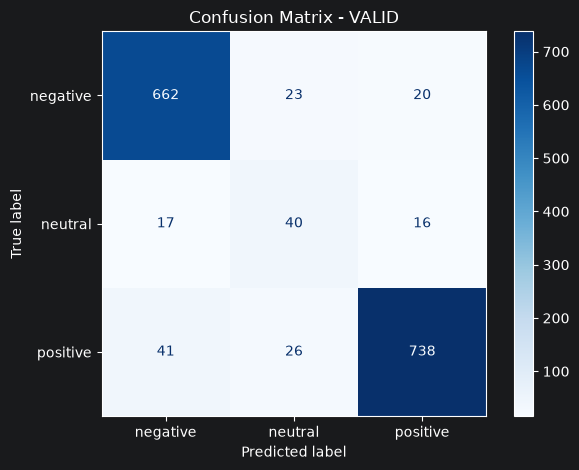

In [28]:
eval_loss, eval_labels, eval_predictions = evaluate(model, eval_loader)
accuracy = accuracy_score(eval_labels, eval_predictions)
macro_f1 = f1_score(eval_labels, eval_predictions, average="macro")
weighted_f1 = f1_score(eval_labels, eval_predictions, average="weighted")

print(f"Accuracy:    {accuracy:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")
print(classification_report(
    eval_labels, eval_predictions, labels=range(len(LABEL_NAMES)),
    target_names=LABEL_NAMES, digits=4, zero_division=0,
))

cm = confusion_matrix(eval_labels, eval_predictions, labels=range(len(LABEL_NAMES)))
print("Confusion matrix:")
print(cm)
ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(
    cmap="Blues", values_format="d"
)
plt.title(f"Confusion Matrix - {SPLIT.upper()}")
plt.tight_layout()
plt.show()

## 8. Validation predictions and error analysis

For validation only, save aligned predictions and inspect 20 mistakes with true neutral examples first. Detailed test analysis is intentionally skipped.

In [29]:
if SPLIT == "valid":
    results_df = pd.DataFrame({
        "sample_id": eval_df["sample_id"],
        "text": eval_df["raw_text"],
        "true_label": [ID_TO_LABEL[idx] for idx in eval_labels],
        "predicted_label": [ID_TO_LABEL[idx] for idx in eval_predictions],
    })
    results_df["is_correct"] = (
        results_df["true_label"] == results_df["predicted_label"]
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    prediction_path = OUTPUT_DIR / "dl_valid_predictions.csv"
    results_df.to_csv(prediction_path, index=False, encoding="utf-8-sig")
    print(f"Validation predictions saved to: {prediction_path.resolve()}")

    errors_df = results_df[~results_df["is_correct"]].copy()
    errors_df["neutral_first"] = errors_df["true_label"].ne("neutral")
    errors_df = errors_df.sort_values("neutral_first", kind="stable").drop(
        columns="neutral_first"
    )
    with pd.option_context("display.max_colwidth", None):
        display(errors_df.head(20))
else:
    print(
        "Test split is reserved for final evaluation; "
        "detailed error analysis is skipped."
    )

Validation predictions saved to: D:\Project Ai\NLP\Vietnamese Student Feedback Classification\Outputs\dl_valid_predictions.csv


,sample_id,text,true_label,predicted_label,is_correct
18,18,em không có bất cứ một lời phê bình nào .,neutral,negative,False
30,30,"thầy cho tự tìm hiểu , và tự tìm hiểu khác với hiểu được vấn đề .",neutral,positive,False
87,87,được 200 điểm là đươc 1 điểm quá trình .,neutral,positive,False
94,94,tài liệu được cấp thông qua lớp trưởng .,neutral,positive,False
117,117,sự nhiệt tình .,neutral,positive,False
154,154,"theo như danh sách phòng đào tạo đưa xuống , lớp học có gần 140 sinh viên đăng kí .",neutral,negative,False
172,172,thầy tiếp tục giảng bài .,neutral,negative,False
189,189,không áp lực khi học tập .,neutral,negative,False
239,239,"phần đầu môn này nói về những chủ đề đại loại như "" làm thế nào để thành công "" , "" thói quen người thành công "" hay là bàn về tương lai vdotv .",neutral,negative,False
489,489,"đôi lúc thầy "" chia sẻ "" hơi nhiều thời gian và việc học vào chương trình thì bị bớt lại nhưng điều này cũng không mấy ảnh hưởng gì .",neutral,negative,False


## 9. Save the checkpoint

Save the trained classifier, project vocabulary, tokenizer name, and compact embedding metadata required by `predict.py`. The full external Word2Vec model is not included.

In [30]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "label_to_id": LABEL_TO_ID,
        "id_to_label": ID_TO_LABEL,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "embedding_dim": EMBEDDING_DIM,
        "hidden_dim": HIDDEN_DIM,
        "tokenizer_name": "underthesea",
        "pretrained_embedding": {
            "name": "sonvx/word2vecVN Vietnamese Wikipedia Word2Vec",
            "filename": WORD2VEC_PATH.name,
            "source": WORD2VEC_SOURCE,
            "format": "word2vec binary (gzip-compressed)",
            "dimension": EMBEDDING_DIM,
        },
    },
    MODEL_PATH,
)
print(f"Checkpoint saved to: {MODEL_PATH.resolve()}")

Checkpoint saved to: D:\Project Ai\NLP\Vietnamese Student Feedback Classification\models\lstm_sentiment.pt
